In [51]:
from typing import TypedDict,Annotated,Literal
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel ,Field
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [52]:
load_dotenv()

True

In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI

# First model (kept as requested)
generator_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3.1-flash-lite",
    temperature=0.2,
    max_output_tokens=256
)

# Evaluator LLM (Updated to Gemini 2.5 Flash)
evaluator_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3.1-flash-lite",
    temperature=0.2,
    max_output_tokens=1024
)

# Optimized LLM (Updated to Gemini 2.0 Flash)
optimized_llm = ChatGoogleGenerativeAI(
    model="models/gemini-3.5-flash-lite",
    temperature=0.2,
    max_output_tokens=256
)

In [54]:
optimized_llm.invoke("Do you know about Air polution in Bangladesh?? how can we reduce it?").content

e:\Learnig\Learn AgenticAI\FirstAgenticAI\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'models/gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


[{'type': 'text',
  'text': 'Yes, I am very familiar with the severe air pollution crisis in Bangladesh, particularly in Dhaka, which frequently ranks as one of the most polluted cities in the world according to the Air Quality Index (AQI). \n\nDuring the dry winter months, the air quality often reaches "hazardous" levels. This is driven by several major sources:\n1. **Brick Kilns:** Hundreds of traditional, energy-inefficient brick kilns operate around major cities, especially during the dry season, emitting massive amounts of black carbon and particulate matter (PM2.5).\n2. **Vehicular Emissions:** A large number of old, poorly maintained vehicles, combined with heavy traffic congestion, release high levels of exhaust.\n3. **Construction Dust:** Unregulated real estate development and road construction generate enormous amounts of airborne dust without proper suppression techniques.\n4. **Industrial Pollution:** Factories often lack proper emission control systems.\n5. **Transboundar

In [55]:
evaluator_llm.invoke("Do you know about Air polution in Bangladesh?? how can we reduce it?").content

[{'type': 'text',
  'text': 'Yes, I am very familiar with the situation. Air pollution in Bangladesh is a critical public health crisis. According to the *World Air Quality Report*, Bangladesh consistently ranks as one of the most polluted countries in the world, with Dhaka frequently topping the list of cities with the worst air quality.\n\n### Why is it so bad?\nThe pollution is driven by a combination of rapid urbanization, industrialization, and geographical factors:\n1.  **Brick Kilns:** Thousands of traditional, inefficient brick kilns operate around Dhaka and other cities, burning coal and wood.\n2.  **Vehicular Emissions:** Old, poorly maintained vehicles and heavy traffic congestion release massive amounts of particulate matter (PM2.5).\n3.  **Construction Dust:** Unregulated construction projects in cities like Dhaka generate enormous amounts of dust without proper mitigation measures.\n4.  **Industrial Waste:** Factories often lack proper filtration systems, releasing toxic 

In [56]:
generator_llm.invoke("Do you know about Air polution in Bangladesh?? how can we reduce it?").content

[{'type': 'text',
  'text': 'Yes, air pollution in Bangladesh is a critical public health crisis. According to the World Air Quality Report, Bangladesh consistently ranks as one of the most polluted countries in the world, with Dhaka frequently topping the list of cities with the worst air quality.\n\n### The Causes of Air Pollution in Bangladesh\nThe pollution is driven by a combination of rapid urbanization, industrialization, and specific local practices:\n\n1.  **Construction and Road Dust:** Unregulated construction projects and poorly maintained, dusty roads are major contributors to Particulate Matter (PM2.5).\n2.  **Vehicle Emissions:** A large number of old, poorly maintained vehicles (especially diesel-run trucks and buses) emit thick black smoke.\n3.  **Brick Kilns:** Thousands of traditional, coal-fired brick kilns operating around major cities are a primary source of toxic emissions.\n4.  **Industrial Waste:** Factories, particularly in the textile and leather sectors, oft

In [67]:
#
import operator
class TweetState(TypedDict):

    topic:str
    tweet:str
    evaluation:Literal["approved",'needs_improvement']

    feedback:str
    iteration:int
    max_iter:int
    tweet_history:Annotated[list[str],operator.add]
    feedback_history:Annotated[list[str],operator.add]

In [68]:
from langchain_core.messages import SystemMessage, HumanMessage

def generate_tweet(state: TweetState) -> dict:
    messages = [
        SystemMessage(content="You are a funny, clever, and engaging Twitter/X influencer. Your tweets are witty, relatable, punchy, and short. Use light sarcasm or humor where appropriate."),
        HumanMessage(content=f"""Write a single high-engagement tweet about the following topic or context:

"{state.get('topic', state.get('input', ''))}"

Rules:
- Do not use question-answer format. 
- Keep it under 280 characters.
- Do not use generic corporate phrases or hashtags.
- Use observational humor, irony, sarcasm or cultural references.
- Use simple day-to-day english.
- Output ONLY the tweet text directly, with no quotes or explanation.
""")
    ]
    
    # Store the AIMessage object directly without appending .content here
    response = generator_llm.invoke(messages)

    # Extract text cleanly whether content is returned as a list or string
    if isinstance(response.content, list):
        tweet_text = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part) 
            for part in response.content
        )
    else:
        tweet_text = str(response.content)
    
    return {"tweet": tweet_text.strip(),"tweet_history":[response]}

In [69]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage


class TweetEvaluation(BaseModel):
    is_funny: bool = Field(
        description="True if the tweet is genuinely witty, clever, and viral-ready; False if plain, weak, or cringey."
    )
    feedback: str = Field(
        description="Specific, actionable feedback on how to improve the punchline, phrasing, or rhythm."
    )


evaluator_structured = evaluator_llm.with_structured_output(
    TweetEvaluation, 
    method="json_schema"  # Guarantees rigid JSON schema enforcement
)


def evaluate_tweet(state: TweetState) -> dict:
    tweet = state.get("tweet", "")
    topic = state.get("topic", "")

    messages = [
        SystemMessage(
            content="You are an elite Twitter/X comedy writer, viral content strategist, and ruthless critic."
        ),
        HumanMessage(
            content=f"""Analyze and evaluate the following generated tweet against viral Twitter standards.

Target Topic: "{topic}"
Generated Tweet: "{tweet}"

Evaluation Rubric and Criteria:
1. Humor and Wit: Is the joke or premise clever? Does it avoid overused tropes, lazy puns, or corporate cringe?
2. Brevity and Punchiness: Is every word necessary? Could the setup or punchline be trimmed for tighter comedic timing?
3. Relatability and Virality: Would a real user retweet or quote-tweet this, or does it sound like an AI trying to write a joke?
4. Tone and Style: Does it sound like an authentic influencer on Twitter/X (casual, witty, punchy)?

Instructions:
- Provide sharp, constructive feedback focusing on what works and what exact phrasing changes would make it funnier or hit harder.
- Set is_funny to True ONLY if the tweet genuinely lands a strong comedic punchline and is ready to post.
"""
        )
    ]

    evaluation = evaluator_structured.invoke(messages)

    # Map boolean to your TweetState's evaluation Literal ("approved" | "needs_improvement")
    status = "approved" if evaluation.is_funny else "needs_improvement"

    return {
        "evaluation": status,
        "feedback": evaluation.feedback,
        'feedback_history':[evaluation.feedback]
    }

In [70]:
from langchain_core.messages import SystemMessage, HumanMessage

def optimized_tweet(state: TweetState) -> dict:
    topic = state.get("topic", "")
    current_tweet = state.get("tweet", "")
    feedback = state.get("feedback", "")
    current_iteration = state.get("iteration", 0)

    messages = [
        SystemMessage(
            content="You are an expert Twitter/X editor and viral comedy strategist. "
                    "Your job is to rewrite and polish tweets based on feedback to make them funnier, punchier, and more engaging."
        ),
        HumanMessage(
            content=f"""Improve the following tweet based on the evaluator feedback.

Topic: "{topic}"
Current Tweet: "{current_tweet}"
Evaluator Feedback: "{feedback}"

Instructions:
1. Apply the feedback to fix any weak setups, awkward phrasing, or flat punchlines.
2. Keep it under 280 characters.
3. Do not use question-answer format.
4. Output ONLY the revised tweet text with no extra commentary, quotes, or explanations.
"""
        )
    ]

    # Store the AIMessage response
    response = optimized_llm.invoke(messages)

    # Safely convert content list to string before calling .strip()
    if isinstance(response.content, list):
        revised_tweet = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in response.content
        )
    else:
        revised_tweet = str(response.content)

    return {
        "tweet": revised_tweet.strip(),
        "iteration": current_iteration + 1,
        'tweet_history':[response]
    }

In [71]:
def route_approval(state: TweetState) -> str:
    # Stop looping if approved or if maximum iterations are reached
    if state["evaluation"] == "approved" or state["iteration"] >= state["max_iter"]:
        return "approved"

    else:

        return "needs_improvement"

In [72]:
graph=StateGraph(TweetState)


graph.add_node("generate",generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node("optimize",optimized_tweet)

graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")

# Pass route_approval as a function reference (no parentheses)
graph.add_conditional_edges(
    "evaluate",
    route_approval,
    {
        "approved": END,
        "needs_improvement": "optimize"
    }
)

graph.add_edge("optimize",'evaluate')



workflow=graph.compile()

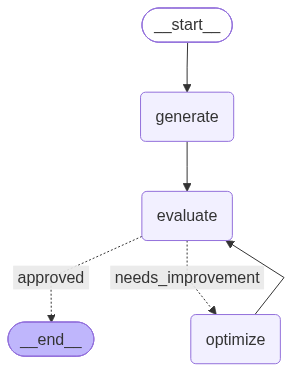

In [73]:
workflow

In [74]:
initial_state={

    "topic":"Bangladesh Railways",
    "iteration":1,
    "max_iter":5
}

In [75]:
workflow.invoke(initial_state)

e:\Learnig\Learn AgenticAI\FirstAgenticAI\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'models/gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'Bangladesh Railways',
 'tweet': "Bangladesh Railways doesn't have a schedule, they have a mood board. ETA is just a suggestion for people who still believe in fairytales.",
 'evaluation': 'approved',
 'feedback': "The 'mood board' angle is excellent and feels very current. To make it punchier, tighten the second sentence: 'ETA is just a suggestion for people who still believe in fairytales' is a bit wordy. Try: 'The ETA is just a suggestion for people who still believe in fairytales.' or even sharper: 'The ETA is just a suggestion for people who still believe in magic.' It's ready to post as is, but cutting 'Bangladesh Railways' to just 'The train schedule' might make it feel more like a relatable observation than a formal complaint.",
 'iteration': 2,
 'max_iter': 5,
 'tweet_history': [AIMessage(content=[{'type': 'text', 'text': 'Bangladesh Railways is the only place where "estimated time of arrival" is just a creative writing exercise and the train schedule is more of a su

In [83]:
initial_state={

    "topic":"Quantum Mechanics",
    "iteration":0,
    "max_iter":5
}
result=workflow.invoke(initial_state)

e:\Learnig\Learn AgenticAI\FirstAgenticAI\venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'models/gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


In [84]:
result

{'topic': 'Quantum Mechanics',
 'tweet': 'Quantum mechanics is just the universe gaslighting you. It’s everywhere, it’s nowhere, and the second you look at it, it changes its story. Honestly, same.',
 'evaluation': 'approved',
 'feedback': "The premise is solid and the 'gaslighting' angle is very current. To make it punchier, cut 'Honestly, same' and replace it with a more specific, cynical observation. Try: 'Quantum mechanics is just the universe gaslighting you. It’s everywhere, it’s nowhere, and the second you look at it, it changes its story. My therapist calls this a personality disorder; physicists call it a Nobel Prize.'",
 'iteration': 1,
 'max_iter': 5,
 'tweet_history': [AIMessage(content=[{'type': 'text', 'text': 'Quantum mechanics is just the universe’s way of saying "I’m not actually here, but I’m also everywhere, and if you look at me too hard, I’m going to change my mind." Honestly, same.', 'extras': {'signature': 'EnEKbwFpFH0T0SZiemE6XDP0nY8n+CyZgioTrWS2kAGtr3ReWiDjouYq

In [85]:
# initial_state = {
#     "topic": "Bangladesh Railways",
#     "iteration": 0,
#     "max_iter": 5
# }

# # Stream state updates step-by-step
# for event in workflow.stream(initial_state):
#     for node_name, node_output in event.items():
#         print(f"\n--- Node: {node_name} ---")
        
#         if node_name == "generate":
#             print(f"Generated Tweet:\n{node_output.get('tweet')}")
            
#         elif node_name == "evaluate":
#             print(f"Status: {node_output.get('evaluation')}")
#             print(f"Feedback: {node_output.get('feedback')}")
            
#         elif node_name == "optimize":
#             print(f"Iteration: {node_output.get('iteration')}")
#             print(f"Optimized Tweet:\n{node_output.get('tweet')}")